# Pertemuan 5 - Dashboard Visualisasi Data

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

## Tujuan Praktikum

Notebook ini membuat dashboard visualisasi sederhana berisi bar chart, histogram dengan KDE, boxplot, dan scatter plot untuk membaca pola pada data transaksi restoran.

(244, 6)
total_bill    float64
tip           float64
sex            object
day            object
time           object
size            int64
dtype: object
       total_bill     tip    size
count      244.00  244.00  244.00
mean        27.16    4.27    2.72
std         12.65    2.16    1.06
min          6.85    1.00    1.00
25%         17.36    2.74    2.00
50%         24.80    3.78    2.00
75%         34.06    5.66    3.25
max         67.94   12.88    6.00
   total_bill   tip     sex   day    time  size
0       14.28  2.89    Male  Thur   Lunch     2
1       19.98  4.25    Male   Sun  Dinner     4
2       26.65  3.10  Female   Sat  Dinner     1
3       17.47  2.36    Male   Sat  Dinner     4
4       61.58  9.61    Male   Sun  Dinner     2
Dashboard tersimpan sebagai dashboard_tips.png


<string>:60: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


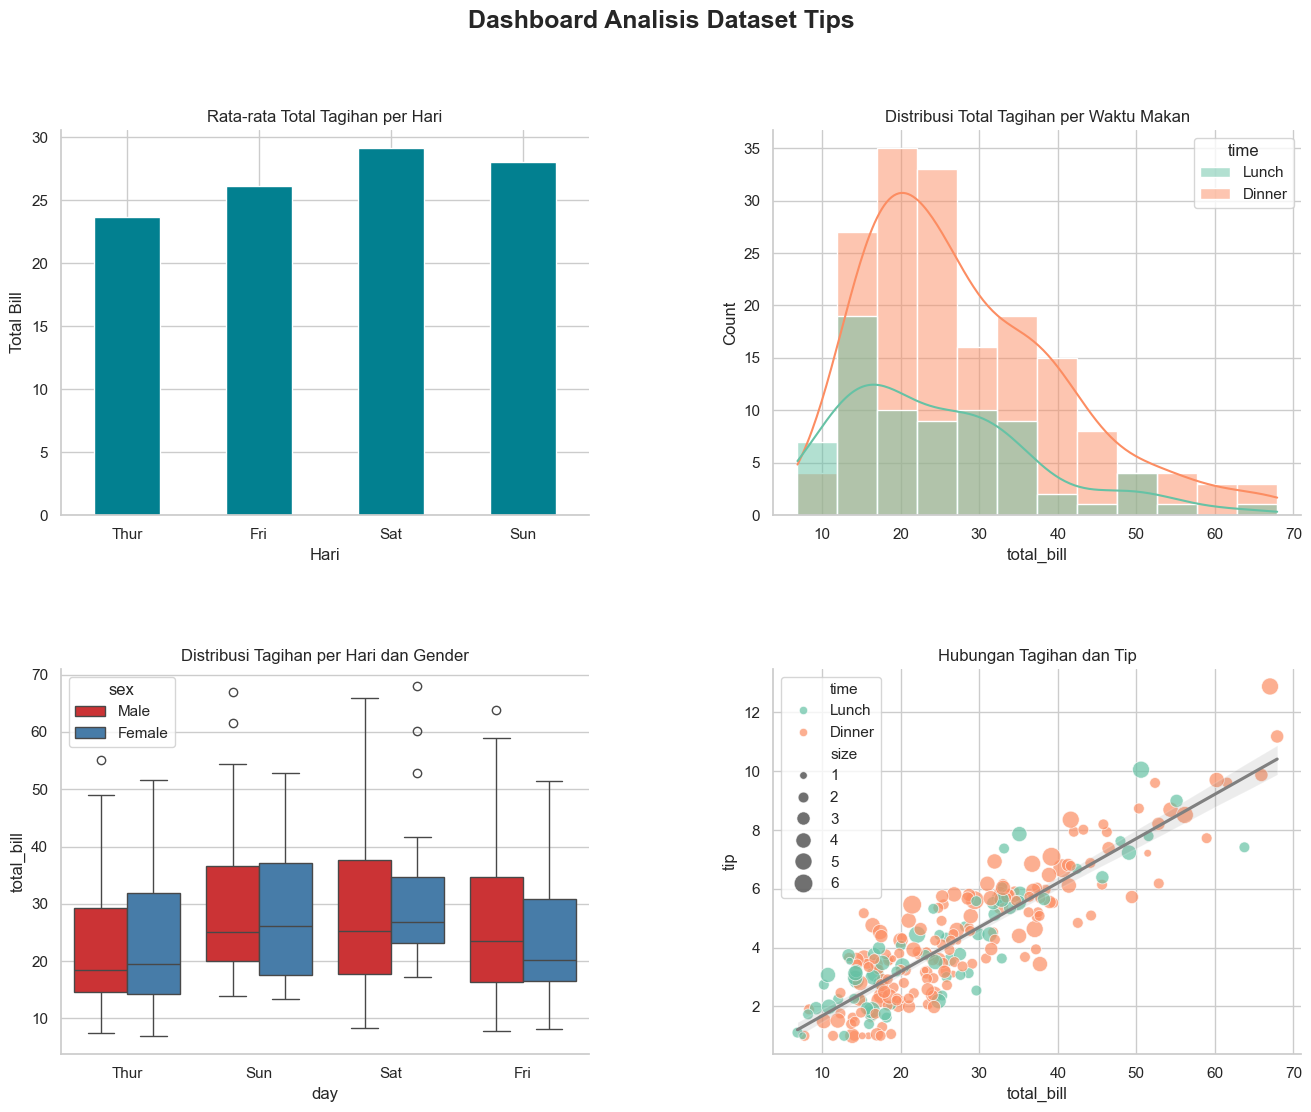

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Load dataset sintetis tips
np.random.seed(7)
n = 244
hari = np.random.choice(["Thur", "Fri", "Sat", "Sun"], size=n, p=[0.25, 0.12, 0.36, 0.27])
waktu = np.array(["Lunch" if h == "Thur" else np.random.choice(["Lunch", "Dinner"]) if h == "Fri" else "Dinner" for h in hari])
jenis_kelamin = np.random.choice(["Male", "Female"], size=n, p=[0.62, 0.38])
jumlah_tamu = np.random.choice([1, 2, 3, 4, 5, 6], size=n, p=[0.04, 0.48, 0.22, 0.18, 0.05, 0.03])
total_bill = np.random.gamma(shape=2.2, scale=9.0, size=n) + 5 + (hari == "Sat") * 3 + (hari == "Sun") * 4
tip = total_bill * (0.11 + 0.07 * np.random.rand(n)) + jumlah_tamu * 0.12 + np.random.normal(0, 0.8, n)
tip = np.clip(tip, 1, None)
df = pd.DataFrame({"total_bill": total_bill.round(2), "tip": tip.round(2), "sex": jenis_kelamin, "day": hari, "time": waktu, "size": jumlah_tamu})

print(df.shape)
print(df.dtypes)
print(df.describe().round(2))
print(df.head())

# Setup figure
sns.set_theme(style="whitegrid", palette="Set2")
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Dashboard Analisis Dataset Tips", fontsize=18, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# Grafik 1: Bar chart
avg_by_day = df.groupby("day")["total_bill"].mean().reindex(["Thur", "Fri", "Sat", "Sun"])
avg_by_day.plot(kind="bar", ax=ax1, color="#028090", edgecolor="white")
ax1.set_title("Rata-rata Total Tagihan per Hari")
ax1.set_xlabel("Hari")
ax1.set_ylabel("Total Bill")
ax1.tick_params(axis="x", rotation=0)
ax1.spines[["top", "right"]].set_visible(False)

# Grafik 2: Histogram + KDE
sns.histplot(data=df, x="total_bill", hue="time", kde=True, palette="Set2", ax=ax2)
ax2.set_title("Distribusi Total Tagihan per Waktu Makan")
ax2.spines[["top", "right"]].set_visible(False)

# Grafik 3: Boxplot
sns.boxplot(data=df, x="day", y="total_bill", hue="sex", palette="Set1", ax=ax3)
ax3.set_title("Distribusi Tagihan per Hari dan Gender")
ax3.spines[["top", "right"]].set_visible(False)

# Grafik 4: Scatter plot
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", size="size", sizes=(30, 180), palette="Set2", alpha=0.7, ax=ax4)
sns.regplot(data=df, x="total_bill", y="tip", scatter=False, color="gray", ax=ax4)
ax4.set_title("Hubungan Tagihan dan Tip")
ax4.spines[["top", "right"]].set_visible(False)

plt.savefig("dashboard_tips.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard tersimpan sebagai dashboard_tips.png")


## Kesimpulan

Pada pertemuan ini saya mempelajari cara menyusun beberapa grafik menjadi satu dashboard analisis. Visualisasi membantu melihat rata-rata tagihan per hari, distribusi tagihan, perbandingan kategori, serta hubungan antara total tagihan dan tip. Keterbatasannya adalah dataset dibuat sintetis, sehingga interpretasi hanya digunakan untuk latihan visualisasi.